# 15 - Shifted MNIST: where FNNs actually break

**Section:** FNNs | **Prereqs:** `FNNs/ScrambledMNIST.ipynb` | **Next:** `FNNs/CodeChallengeMissing7.ipynb`

The companion to the scrambled experiment, and the opposite result.

Train on normal MNIST, then roll every **test** image sideways by a random
-10..+10 pixels. Accuracy collapses. A human reads a shifted digit without
effort; the network cannot, because a digit shifted by 8 pixels lands on 784
completely different input features, and the weights attached to those features
were never trained for it.

**Scrambled vs shifted, side by side**

| Experiment | Train and test transformed the same way? | Accuracy |
|---|---|---|
| Scrambled | yes (one fixed permutation) | unchanged |
| Shifted | no (test only) | collapses |

**The two lessons**
1. An FNN has no *translation invariance*. A CNN gets it nearly for free,
   because the same kernel is applied at every position.
2. More generally: a model only handles variation it saw during training. Adding
   the same shifts to the training set fixes this - that is data augmentation
   (`More on Data/`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
%matplotlib inline

#### We only are going to shift/roll the test images, not the train images

In [55]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

In [56]:
# Flatten both splits to 784-vectors.
label = data.targets.to('cuda')
data = data.data.view(-1,784)

test_label = test_data.targets.to('cuda')
test_data = test_data.data.view(-1,784)

In [57]:
# Fit the scaler on train, apply to test - the correct order.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data = scaler.fit_transform(data)

test_data = scaler.transform(test_data)


In [58]:
# Tensors on GPU, standard loaders.
# Now lets get the data sorted on the GPU()

data = torch.tensor(data,dtype=torch.float,device='cuda')
test_data = torch.tensor(test_data,dtype=torch.float,device='cuda')

train_data = TensorDataset(data,label)
test_data = TensorDataset(test_data,test_label)


bs = 16
train_loader = DataLoader(train_data,batch_size=bs, shuffle=True,drop_last=True)
test_loader = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [59]:
# torch.roll shifts pixels along an axis and wraps them around the edge.
# The image must be reshaped to 28x28 first: rolling a flat 784-vector would
# slide pixels across row boundaries instead of shifting the picture.
# Shifting the test data

img = test_loader.dataset.tensors[0][0,:]

imgS = torch.roll(img.cpu().reshape(28,28),8 ,dims=1)

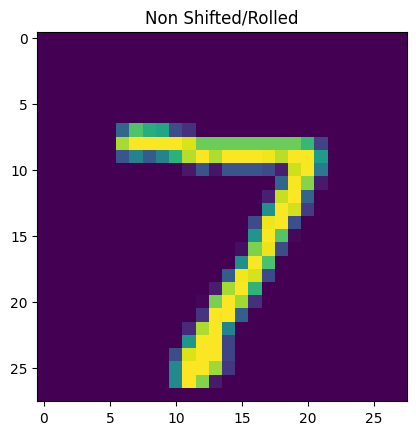

In [60]:
# The original digit.
plt.imshow(img.cpu().reshape(28,28));
plt.title("Non Shifted/Rolled");

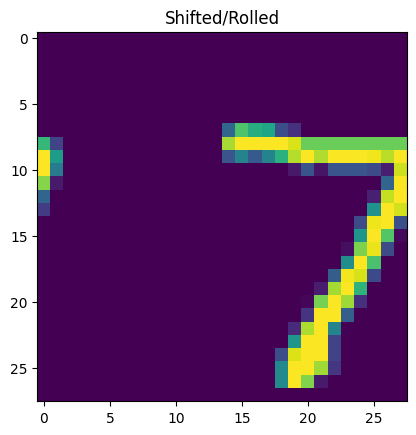

In [61]:
# The same digit rolled 8 columns to the right - obviously the same number to
# a human eye.
plt.imshow(imgS.cpu().reshape(28,28))
plt.title("Shifted/Rolled");

In [63]:
# Roll EVERY test image by its own random amount in [-10, +10] columns.
# The training set is untouched, which is the whole design: the model is being
# tested on a kind of variation it never saw.
# Note this mutates the tensor inside the dataset in place, so re-running the
# cell shifts the already-shifted images again.
# Now we shift every image in test_loader

for i in range(test_loader.dataset.tensors[0].shape[0]):

   img = test_loader.dataset.tensors[0][i,:]


   randomRollInt = np.random.randint(-10,11) # Creating random numbers to shift by

   imgS = torch.roll(img.reshape(28,28), randomRollInt, dims=1)


   test_loader.dataset.tensors[0][i,:] = imgS.reshape(1,-1)


In [68]:
# 784-128-128-10, exactly the architecture that hit ~95% on unshifted MNIST.
class classifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784,128)
    self.fc1 = nn.Linear(128,128)
    self.output_layer = nn.Linear(128,10)

  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    return self.output_layer(x)

In [76]:
# Standard training function. Train accuracy is measured on unshifted images,
# test accuracy on shifted ones - so the gap between the two curves is entirely
# caused by the shift.
def train_model():

  model = classifier().to('cuda')

  lr = 1e-4
  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr = lr)
  epochs = 50

  test_acc= []
  train_acc = []
  losses = []

  for epoch in range(epochs):

    model.train()
    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append( 100 * torch.mean( (torch.argmax(yhat,dim=1) == y).float() ).cpu() )


    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Epoch {epoch} | Loss : {losses[epoch]}')

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      preds = model(X)
      test_acc.append( 100 * torch.mean( (torch.argmax(preds,dim=1) == Y).float() ).cpu() )


  return train_acc, test_acc,losses, model

In [77]:
# Train it.
train_acc, test_acc,losses, model = train_model()

Epoch 0 | Loss : 0.5121236708849668
Epoch 10 | Loss : 0.06140799903723722
Epoch 20 | Loss : 0.020171420790518944
Epoch 30 | Loss : 0.005649275795498003
Epoch 40 | Loss : 0.0015017985043793486
Epoch 49 | Loss : 0.0007298565773698635


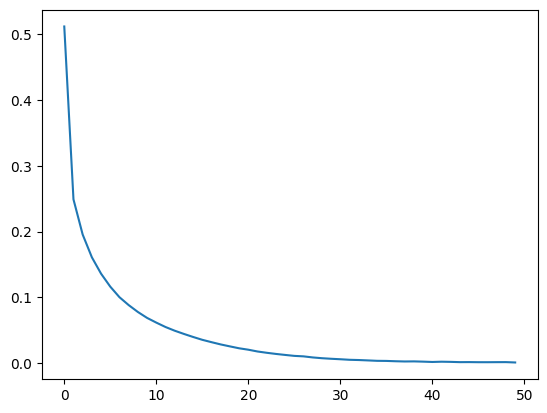

In [78]:
# Loss on the training set falls normally: the model is learning fine.
plt.plot(losses);

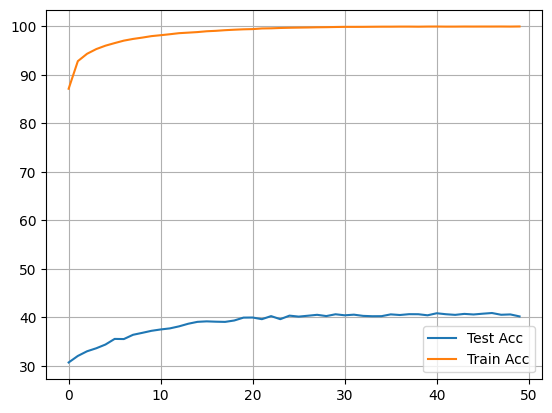

In [79]:
# The result. Train accuracy climbs as usual while test accuracy stays near the
# floor. Nothing is wrong with the training - the test distribution simply moved.
plt.plot(test_acc,label="Test Acc")
plt.plot(train_acc, label="Train Acc")
plt.grid()
plt.legend();

In [80]:
# The two final numbers. This gap is what CNNs and data augmentation exist to
# close.
train_acc[-1], test_acc[-1]

(np.float32(99.99333), tensor(40.2000))

In [81]:
# One shifted test image.
a = test_loader.dataset.tensors[0][0,:]

In [83]:
# Predicting on a single sample: PyTorch accepts the unbatched (784,) vector
# here because Linear broadcasts, but the habit to build is x.unsqueeze(0) to
# make an explicit batch of 1.
prd = model(a)

In [93]:
# 10 logits, one per digit - a prediction the model makes confidently and gets
# wrong.
prd.shape

torch.Size([10])

# In conclusion, feed‑forward neural networks tend to underperform on image‑processing tasks because they don’t capture the spatial structure inherent in image data.